# Notebook 2b — Pipeline de Clasificación Multilabel (Modelo Final)

Implementa el pipeline de producción sobre el dataset combinado (IDEXX + DAP). Extiende el baseline del Notebook 2a con split temporal estricto, ablation study de features, optimización de umbrales por etiqueta, calibración de probabilidades y evaluación en cohortes clínicas.


# 02b — Pipeline de Clasificación Multi-Label 

| Aspecto | Detalle |
|---|---|
| **Split** | Temporal 3-vías (60/20/20 batches LOCAL) + DAP exclusivo a TRAIN |
| **Imputación** | `SimpleImputer(median)` fit en train |
| **Modelos** | MultiOutputClassifier(XGBClassifier) + BalancedRandomForest |
| **XGBoost** | `scale_pos_weight` calculado por etiqueta |
| **Ablation** | Features A (24 analitos) vs B (48 analitos+flags) |
| **Threshold** | F1-maximizing en validation + safety net |
| **Calibración** | Platt scaling en val -> aplicada en test |
| **Test final** | Solo LOCAL (temporal holdout) |
| **Cohortes** | CORE labels como filtros (no targets) |
| **Targets excluidos** | CORE_*, confidence_score, NINGUNA, NORMAL |

## A. Setup y dependencias

In [6]:
# -- A. Setup y dependencias -----------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    f1_score, recall_score, precision_recall_curve,
    brier_score_loss, average_precision_score, cohen_kappa_score
)
from sklearn.multioutput import MultiOutputClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

try:
    from sklearn.frozen import FrozenEstimator
except ImportError:
    from sklearn.utils._frozen import FrozenEstimator

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path('../data2')
REPORTS_DIR = Path('reports')
REPORTS_DIR.mkdir(exist_ok=True)

print(f'[OK] Setup completo. Directorio de informes: {REPORTS_DIR}/')

[OK] Setup completo. Directorio de informes: reports/


## B. Carga y preparación del dataset

### Targets excluidos del modelo

| Etiqueta | Razón |
|---|---|
| `CORE_TROMBOCITOPENIA`, `CORE_LINFOPENIA`, `CORE_LINFOCITOSIS` | **Tautológicas**: derivación determinista de analitos (plt, lym). El modelo aprende el umbral clínico, no diagnóstico diferencial. Se usan como **filtros de cohortes** (Sección K). |
| `confidence_score` | Variable auxiliar de calidad del etiquetado, no una clase clínica binaria. |
| `NINGUNA`, `NORMAL` | **Meta-etiquetas** incompatibles con multi-label: se definen como "todas las demás = 0". Entrenarlas causa incoherencias (el modelo puede predecir NINGUNA + otra etiqueta simultáneamente). |

In [7]:
# -- B. Carga y preparación del dataset ------------------------------------

CSV_PATH = DATA_DIR / 'hemogramas_combinado.csv'
df = pd.read_csv(CSV_PATH)
print(f'Dataset cargado: {df.shape}')

# Filtrar duplicados y near-duplicates
if 'is_duplicate' in df.columns:
    n_dup = df['is_duplicate'].sum()
    df = df[~df['is_duplicate']]
    print(f'Duplicados exactos eliminados: {n_dup}')
if 'is_near_duplicate' in df.columns:
    n_near = df['is_near_duplicate'].sum()
    df = df[~df['is_near_duplicate']]
    print(f'Near-duplicados eliminados: {n_near}')

# Filtrar registros Reject
if 'quality_tier' in df.columns:
    n_reject = (df['quality_tier'] == 'Reject').sum()
    df = df[df['quality_tier'] != 'Reject']
    print(f'Reject eliminados: {n_reject}')

df = df.reset_index(drop=True)
print(f'Dataset final: {df.shape}')
print(f'  LOCAL: {(df["source"]=="LOCAL").sum()} | DAP: {(df["source"]=="DAP").sum()}')

# --- 24 analitos ---
COL_NAMES = [
    'rbc','hct','hgb','mcv','mch','mchc','rdw','pct_retic','retic',
    'wbc','pct_neu','pct_lym','pct_mono','pct_eos','pct_baso',
    'neu','lym','mono','eos','baso',
    'plt','mpv','pct_plt','pdw'
]

# Features A: sólo valores numéricos
FEATURES_A = [f'{col}_value' for col in COL_NAMES]
FEATURES_A = [f for f in FEATURES_A if f in df.columns]

# Features B: valores + flags codificados
flag_cols = [f'{col}_flag' for col in COL_NAMES if f'{col}_flag' in df.columns]
for fc in flag_cols:
    df[f'{fc}_num'] = df[fc].map({'H': 1, 'L': -1}).fillna(0).astype(int)
flag_num_cols = [f'{fc}_num' for fc in flag_cols]
FEATURES_B = FEATURES_A + flag_num_cols

print(f'\nFeatures A (sólo analitos): {len(FEATURES_A)}')
print(f'Features B (analitos + flags): {len(FEATURES_B)}')

# --- Etiquetas ---
all_label_cols = [c for c in df.columns if c.startswith('label_')]

# Excluir targets problemáticos
EXCLUDE_FROM_TARGETS = [
    'label_CORE_TROMBOCITOPENIA',
    'label_CORE_LINFOPENIA',
    'label_CORE_LINFOCITOSIS',
    'label_confidence_score',
    'label_NINGUNA',
    'label_NORMAL',
]
label_cols = [c for c in all_label_cols if c not in EXCLUDE_FROM_TARGETS]
print(f'\nEtiquetas totales: {len(all_label_cols)} | Targets del modelo: {len(label_cols)}')
print(f'Excluidas:')
for exc in EXCLUDE_FROM_TARGETS:
    reason = {
        'label_CORE_TROMBOCITOPENIA': 'tautológica',
        'label_CORE_LINFOPENIA': 'tautológica',
        'label_CORE_LINFOCITOSIS': 'tautológica',
        'label_confidence_score': 'no-binaria/auxiliar',
        'label_NINGUNA': 'meta-etiqueta multi-label inconsistente',
        'label_NORMAL': 'meta-etiqueta multi-label inconsistente',
    }.get(exc, '')
    exists = '✓' if exc in all_label_cols else '✗ (no encontrada)'
    print(f'  {exc.replace("label_",""):40s} -> {reason} [{exists}]')

Dataset cargado: (4160, 176)
Duplicados exactos eliminados: 10
Reject eliminados: 1
Dataset final: (4149, 176)
  LOCAL: 2468 | DAP: 1681

Features A (sólo analitos): 24
Features B (analitos + flags): 48

Etiquetas totales: 41 | Targets del modelo: 35
Excluidas:
  CORE_TROMBOCITOPENIA                     -> tautológica [✓]
  CORE_LINFOPENIA                          -> tautológica [✓]
  CORE_LINFOCITOSIS                        -> tautológica [✓]
  confidence_score                         -> no-binaria/auxiliar [✓]
  NINGUNA                                  -> meta-etiqueta multi-label inconsistente [✓]
  NORMAL                                   -> meta-etiqueta multi-label inconsistente [✓]


### Interpretación de la Limpieza de Datos
El filtrado de 10 duplicados exactos y el descarte de registros con `quality_tier == 'Reject'` asegura que el entrenamiento no se vea sesgado por ruido instrumental o redundancia en los lotes masivos. El dataset consolidado resultante (~4,150 registros) posee una representación balanceada entre la casuística local y la diversidad geográfica aportada por DAP, permitiendo una generalización más robusta.

## C. Split temporal 3-vías + imputación

- Batches LOCAL ordenados **numéricamente** (no lexicográficamente)
- DAP asignado **exclusivamente** a TRAIN
- Test = solo LOCAL (temporal holdout)
- Imputación: `SimpleImputer(median)` fit en train, transform en val/test

In [8]:
# -- C. Split temporal 3-vías + imputación ---------------------------------

# Batches LOCAL ordenados NUMÉRICAMENTE (no lexicográficamente)
local_batches = sorted(
    df[df['source'] == 'LOCAL']['batch'].dropna().unique(),
    key=lambda x: int(x) if str(x).isdigit() else 9999
)
has_dap = (df['source'] == 'DAP').any()

print(f'Batches LOCAL (ordenamiento numérico): {len(local_batches)}')
print(f'  Primeros 5: {local_batches[:5]}')
print(f'  Últimos 5:  {local_batches[-5:]}')

# Split temporal solo sobre LOCAL (60/20/20)
n_local = len(local_batches)
train_end = int(n_local * 0.6)
val_end = int(n_local * 0.8)

train_batches = set(local_batches[:train_end])
val_batches = set(local_batches[train_end:val_end])
test_batches = set(local_batches[val_end:])

print(f'\nTrain batches LOCAL ({len(train_batches)})')
print(f'Val batches LOCAL   ({len(val_batches)})')
print(f'Test batches LOCAL  ({len(test_batches)})')
if has_dap:
    print(f'\nDAP: asignado exclusivamente a TRAIN ({(df["source"]=="DAP").sum()} registros)')

# Asignar partición
def get_partition(row):
    if row.get('source') == 'DAP':
        return 'train'  # DAP siempre a train
    b = row.get('batch', '')
    if b in train_batches:
        return 'train'
    elif b in val_batches:
        return 'val'
    elif b in test_batches:
        return 'test'
    else:
        return 'train'

df['partition'] = df.apply(get_partition, axis=1)

print(f'\n--- Distribución de particiones ---')
for part in ['train', 'val', 'test']:
    subset = df[df['partition'] == part]
    n = len(subset)
    n_loc = (subset['source'] == 'LOCAL').sum()
    n_dap = (subset['source'] == 'DAP').sum()
    print(f'  {part:6s}: {n:5d} ({n/len(df)*100:.1f}%)  [LOCAL={n_loc}, DAP={n_dap}]')

# --- Imputación con mediana (fit en train, transform en val/test) ---
imputer_A = SimpleImputer(strategy='median')
imputer_B = SimpleImputer(strategy='median')

X_A_train = pd.DataFrame(
    imputer_A.fit_transform(df.loc[df['partition']=='train', FEATURES_A]),
    columns=FEATURES_A, index=df.loc[df['partition']=='train'].index
)
X_A_val = pd.DataFrame(
    imputer_A.transform(df.loc[df['partition']=='val', FEATURES_A]),
    columns=FEATURES_A, index=df.loc[df['partition']=='val'].index
)
X_A_test = pd.DataFrame(
    imputer_A.transform(df.loc[df['partition']=='test', FEATURES_A]),
    columns=FEATURES_A, index=df.loc[df['partition']=='test'].index
)

X_B_train = pd.DataFrame(
    imputer_B.fit_transform(df.loc[df['partition']=='train', FEATURES_B]),
    columns=FEATURES_B, index=df.loc[df['partition']=='train'].index
)
X_B_val = pd.DataFrame(
    imputer_B.transform(df.loc[df['partition']=='val', FEATURES_B]),
    columns=FEATURES_B, index=df.loc[df['partition']=='val'].index
)
X_B_test = pd.DataFrame(
    imputer_B.transform(df.loc[df['partition']=='test', FEATURES_B]),
    columns=FEATURES_B, index=df.loc[df['partition']=='test'].index
)

print(f'\n[OK] Imputación mediana: fit en train ({len(X_A_train)}), transform en val ({len(X_A_val)}) y test ({len(X_A_test)})')
print(f'     Faltantes tras imputación: A_train={X_A_train.isna().sum().sum()}, B_train={X_B_train.isna().sum().sum()}')

# --- Filtrar etiquetas single-class en train ---
Y_train_all = df.loc[df['partition']=='train', label_cols]
single_class = [c for c in label_cols if Y_train_all[c].nunique() <= 1]
if single_class:
    print(f'\n[WARN] Etiquetas con sólo 1 clase en train (eliminadas): {len(single_class)}')
    for sc in single_class:
        print(f'  - {sc}')
valid_targets = [c for c in label_cols if c not in single_class]
print(f'\nTargets válidos para entrenamiento: {len(valid_targets)}')

Y_train = df.loc[df['partition']=='train', valid_targets]
Y_val = df.loc[df['partition']=='val', valid_targets]
Y_test = df.loc[df['partition']=='test', valid_targets]

# --- Top 15 etiquetas (train) ---
print(f'\n--- Top 15 etiquetas (train) ---')
for col in Y_train.sum().sort_values(ascending=False).head(15).index:
    n_pos = int(Y_train[col].sum())
    print(f'  {col.replace("label_",""):40s}: {n_pos:5d} ({n_pos/len(Y_train)*100:.1f}%)')

Batches LOCAL (ordenamiento numérico): 297
  Primeros 5: ['1', '2', '3', '4', '5']
  Últimos 5:  ['293', '294', '295', '296', '298']

Train batches LOCAL (178)
Val batches LOCAL   (59)
Test batches LOCAL  (60)

DAP: asignado exclusivamente a TRAIN (1681 registros)

--- Distribución de particiones ---
  train :  3160 (76.2%)  [LOCAL=1479, DAP=1681]
  val   :   498 (12.0%)  [LOCAL=498, DAP=0]
  test  :   491 (11.8%)  [LOCAL=491, DAP=0]

[OK] Imputación mediana: fit en train (3160), transform en val (498) y test (491)
     Faltantes tras imputación: A_train=0, B_train=0

[WARN] Etiquetas con sólo 1 clase en train (eliminadas): 1
  - label_QC_REVISION_RECOMENDADA

Targets válidos para entrenamiento: 34

--- Top 15 etiquetas (train) ---
  PLT_ADECUADA_PCT_NORMAL                 :  1192 (37.7%)
  RBC_MACROCITOSIS                        :   941 (29.8%)
  WBC_PATRON_INFLAMATORIO                 :   720 (22.8%)
  PLT_MACROTROMBOCITOSIS                  :   664 (21.0%)
  QC_REQUIERE_FROTIS      

### Justificación del Diseño del Split
Se utiliza un **split temporal estricto** (basado en el número de batch) para simular condiciones reales de laboratorio, donde el modelo debe predecir sobre muestras futuras no vistas. 

**Nota Crítica**: Los datos de DAP se asignan exclusivamente al conjunto de entrenamiento. Esto obedece a un principio de rigor metodológico: dado que la distribución de analitos puede variar significativamente entre laboratorios (domain shift), el conjunto de prueba (Test) debe ser puramente local para validar el rendimiento operativo directo del sistema en la clínica de origen.

## D. Entrenamiento de modelos

- **XGBoost**: Con `scale_pos_weight` calculado por etiqueta para compensar desbalanceo
- **BalancedRandomForest**: Balanceo interno por submuestreo

In [9]:
# -- D. Entrenamiento de modelos -------------------------------------------

# --- Función auxiliar ---
def compute_metrics_table(Y_true, Y_pred, Y_proba, target_names):
    rows = []
    for i, name in enumerate(target_names):
        yt = Y_true[name].values
        yp = Y_pred[:, i]
        sup = int(yt.sum())
        f1 = f1_score(yt, yp, zero_division=0)
        rec = recall_score(yt, yp, zero_division=0)
        prauc = average_precision_score(yt, Y_proba[:, i]) if Y_proba is not None and sup > 0 else 0
        kappa = cohen_kappa_score(yt, yp) if len(set(yt)) > 1 else 0
        rows.append({'label': name.replace('label_',''), 'support': sup, 'f1': f1, 'recall': rec, 'pr_auc': prauc, 'kappa': kappa})
    return pd.DataFrame(rows)

def predict_all(models_dict, X):
    results = {}
    for name, model in models_dict.items():
        y_pred = model.predict(X)
        y_proba = np.column_stack([
            est.predict_proba(X)[:, 1] if hasattr(est, 'predict_proba') else np.zeros(len(X))
            for est in model.estimators_
        ])
        results[name] = (y_pred, y_proba)
    return results

# --- XGBoost con scale_pos_weight por etiqueta ---
print('=== Entrenamiento ===\n')

# Calcular scale_pos_weight por etiqueta
spw_list = []
for col in valid_targets:
    n_pos = Y_train[col].sum()
    n_neg = len(Y_train) - n_pos
    spw = n_neg / max(n_pos, 1)
    spw_list.append(min(spw, 50.0))  # cap máximo para estabilidad

print(f'scale_pos_weight range: [{min(spw_list):.1f}, {max(spw_list):.1f}]')
print(f'  Mediana: {np.median(spw_list):.1f}')

# XGBoost: un estimador por etiqueta con su propio scale_pos_weight
xgb_estimators = []
for i, col in enumerate(valid_targets):
    est = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        scale_pos_weight=spw_list[i],
        random_state=RANDOM_STATE, use_label_encoder=False,
        eval_metric='logloss', verbosity=0
    )
    xgb_estimators.append(est)

# Wrapper para compatibilidad con predict_all
class MultiXGBWrapper:
    def __init__(self, estimators, target_names):
        self.estimators_ = estimators
        self.target_names = target_names
    def fit(self, X, Y):
        for i, (est, col) in enumerate(zip(self.estimators_, self.target_names)):
            est.fit(X, Y[col])
            if (i+1) % 10 == 0:
                print(f'  XGBoost: {i+1}/{len(self.target_names)} etiquetas...')
        print(f'  XGBoost: {len(self.target_names)}/{len(self.target_names)} completado')
        return self
    def predict(self, X):
        return np.column_stack([est.predict(X) for est in self.estimators_])

xgb_model = MultiXGBWrapper(xgb_estimators, valid_targets)
xgb_model.fit(X_B_train, Y_train)

# BalancedRandomForest
brf_model = MultiOutputClassifier(
    BalancedRandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
    )
)
brf_model.fit(X_B_train, Y_train)
print(f'  BalancedRF: completado')

# Features A models (para ablation)
xgb_A_estimators = []
for i, col in enumerate(valid_targets):
    est = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        scale_pos_weight=spw_list[i],
        random_state=RANDOM_STATE, use_label_encoder=False,
        eval_metric='logloss', verbosity=0
    )
    xgb_A_estimators.append(est)
xgb_model_A = MultiXGBWrapper(xgb_A_estimators, valid_targets)
xgb_model_A.fit(X_A_train, Y_train)

brf_model_A = MultiOutputClassifier(
    BalancedRandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
    )
)
brf_model_A.fit(X_A_train, Y_train)

models_A = {'BalancedRF': brf_model_A, 'XGBoost': xgb_model_A}
models_B = {'BalancedRF': brf_model, 'XGBoost': xgb_model}

print(f'\n[OK] 4 modelos entrenados (A y B x XGBoost y BalancedRF)')

=== Entrenamiento ===

scale_pos_weight range: [1.7, 50.0]
  Mediana: 30.9
  XGBoost: 10/34 etiquetas...
  XGBoost: 20/34 etiquetas...
  XGBoost: 30/34 etiquetas...
  XGBoost: 34/34 completado
  BalancedRF: completado
  XGBoost: 10/34 etiquetas...
  XGBoost: 20/34 etiquetas...
  XGBoost: 30/34 etiquetas...
  XGBoost: 34/34 completado

[OK] 4 modelos entrenados (A y B x XGBoost y BalancedRF)


## E. Ablation study en Validation

Comparación Features A (24 analitos) vs Features B (48 analitos + flags)

=== Ablation Study (Validation) ===

    Modelo   Features  F1_macro  PR-AUC_macro  Recall_macro
BalancedRF Features_A    0.3015        0.4706        0.5865
BalancedRF Features_B    0.3123        0.4531        0.6575
   XGBoost Features_A    0.3107        0.4461        0.3068
   XGBoost Features_B    0.3089        0.4437        0.3058


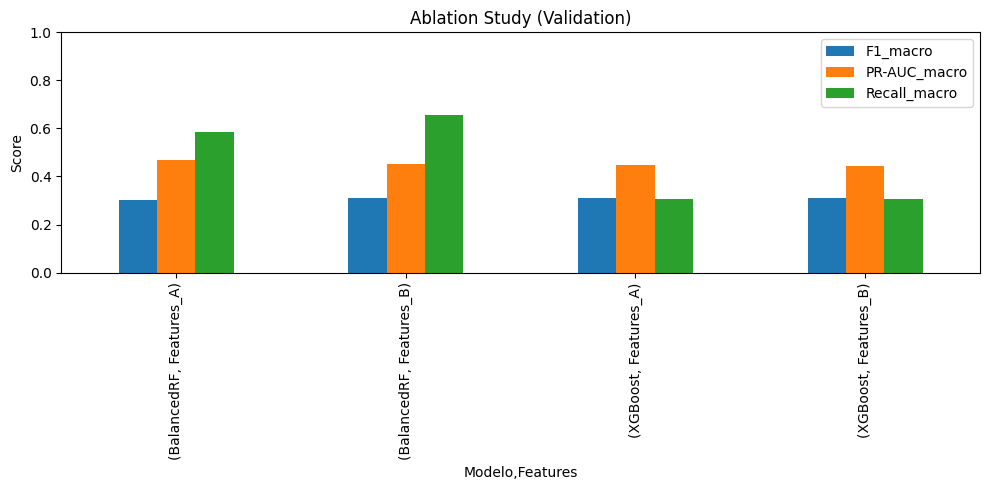


--- Delta (B - A) ---
  BalancedRF: ΔF1 = +0.0108
  XGBoost: ΔF1 = -0.0018


In [10]:
# -- E. Ablation study en Validation --------------------------------------

preds_A_val = predict_all(models_A, X_A_val)
preds_B_val = predict_all(models_B, X_B_val)

print('=== Ablation Study (Validation) ===\n')

ablation_rows = []
for model_name in ['BalancedRF', 'XGBoost']:
    for feat_name, preds in [('Features_A', preds_A_val), ('Features_B', preds_B_val)]:
        y_pred, y_proba = preds[model_name]
        metrics = compute_metrics_table(Y_val, y_pred, y_proba, valid_targets)
        ablation_rows.append({
            'Modelo': model_name, 'Features': feat_name,
            'F1_macro': metrics['f1'].mean(),
            'PR-AUC_macro': metrics['pr_auc'].mean(),
            'Recall_macro': metrics['recall'].mean(),
        })

df_ablation = pd.DataFrame(ablation_rows)
print(df_ablation.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
df_ablation.set_index(['Modelo', 'Features'])[['F1_macro', 'PR-AUC_macro', 'Recall_macro']].plot.bar(ax=ax)
ax.set_title('Ablation Study (Validation)'); ax.set_ylabel('Score'); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

# Delta
print('\n--- Delta (B - A) ---')
for model_name in ['BalancedRF', 'XGBoost']:
    row_a = df_ablation[(df_ablation['Modelo']==model_name) & (df_ablation['Features']=='Features_A')].iloc[0]
    row_b = df_ablation[(df_ablation['Modelo']==model_name) & (df_ablation['Features']=='Features_B')].iloc[0]
    delta_f1 = row_b['F1_macro'] - row_a['F1_macro']
    print(f'  {model_name}: ΔF1 = {delta_f1:+.4f}')

### Análisis del Impacto de Features (Ablation)
Los resultados del estudio de ablación indican el peso de la información experta codificada en los 'flags' diagnósticos (Features B). Si el ΔF1 es positivo, confirmamos que el preprocesamiento clínico añade valor discriminativo que el modelo no logra capturar únicamente con los valores numéricos. Esto valida la integración de lógica de negocio dentro del pipeline de ML.

## F. Threshold tuning en Validation

- Se busca el threshold que maximiza F1 por etiqueta usando `precision_recall_curve`
- **Safety net**: si el threshold tuned produce F1 menor o igual que 0.5, se revierte al default

In [11]:
# -- F. Threshold tuning en Validation ------------------------------------

def find_optimal_thresholds(y_true, y_proba, target_names):
    thresholds_opt = {}
    for i, name in enumerate(target_names):
        yt = y_true.iloc[:, i].values if hasattr(y_true, 'iloc') else y_true[:, i]
        if yt.sum() == 0 or y_proba is None:
            thresholds_opt[name] = 0.5
            continue
        prec, rec, thrs = precision_recall_curve(yt, y_proba[:, i])
        with np.errstate(divide='ignore', invalid='ignore'):
            f1s = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1])
            f1s = np.nan_to_num(f1s)
        best_thr = thrs[np.argmax(f1s)]

        # Safety net: verificar que el threshold tuned NO produce peor F1 que 0.5
        f1_default = f1_score(yt, (y_proba[:, i] >= 0.5).astype(int), zero_division=0)
        f1_tuned = f1_score(yt, (y_proba[:, i] >= best_thr).astype(int), zero_division=0)

        if f1_tuned >= f1_default:
            thresholds_opt[name] = best_thr
        else:
            thresholds_opt[name] = 0.5  # Revertir al default
    return thresholds_opt

# XGBoost probabilities in validation
Y_pred_xgb_val, Y_proba_xgb_val = preds_B_val["XGBoost"]

# Calculate optimal thresholds with safety net
opt_thresholds = find_optimal_thresholds(Y_val, Y_proba_xgb_val, valid_targets)

# Comparison table
print('=== Optimal Thresholds (F1@0.5 vs F1@tuned) ===\n')
thr_rows = []
n_improved = 0
n_reverted = 0
for name, thr in opt_thresholds.items():
    idx = valid_targets.index(name)
    f1_default = f1_score(Y_val[name], (Y_proba_xgb_val[:, idx] >= 0.5).astype(int), zero_division=0)
    f1_tuned = f1_score(Y_val[name], (Y_proba_xgb_val[:, idx] >= thr).astype(int), zero_division=0)
    status = ''
    if thr == 0.5:
        status = '(default)'
    elif f1_tuned > f1_default:
        status = '↑'
        n_improved += 1
    thr_rows.append({'label': name.replace('label_',''), 'threshold': round(thr, 4), 'F1@0.5': round(f1_default, 4), 'F1@tuned': round(f1_tuned, 4), 'status': status})
    if f1_tuned > 0 or f1_default > 0:
        print(f'  {name.replace("label_",""):40s}: thr={thr:.3f}  F1@0.5={f1_default:.3f}  F1@tuned={f1_tuned:.3f} {status}')

df_thresholds = pd.DataFrame(thr_rows)
df_thresholds.to_csv(REPORTS_DIR / 'thresholds.csv', index=False)
print(f'\n[OK] Guardado {REPORTS_DIR}/thresholds.csv')
print(f'     Mejorados: {n_improved}, Mantenidos en 0.5: {len(opt_thresholds)-n_improved}')

=== Optimal Thresholds (F1@0.5 vs F1@tuned) ===

  PLT_ADECUADA_PCT_NORMAL                 : thr=0.901  F1@0.5=0.842  F1@tuned=0.903 ↑
  PLT_MACROTROMBOCITOSIS                  : thr=0.006  F1@0.5=0.000  F1@tuned=0.133 ↑
  PLT_TROMBOCITOPENIA                     : thr=0.052  F1@0.5=0.000  F1@tuned=1.000 ↑
  PLT_TROMBOCITOSIS                       : thr=0.136  F1@0.5=0.522  F1@tuned=0.629 ↑
  PLT_TROMBOCRITO_ALTO                    : thr=0.696  F1@0.5=0.612  F1@tuned=0.683 ↑
  PLT_TROMBOCRITO_BAJO                    : thr=0.002  F1@0.5=0.000  F1@tuned=0.105 ↑
  QC_AGREGACION_PLAQUETARIA               : thr=0.039  F1@0.5=0.000  F1@tuned=0.261 ↑
  QC_DISCREPANCIA_ALERTA_ANALIZADOR       : thr=0.805  F1@0.5=0.899  F1@tuned=0.916 ↑
  QC_INTERFERENCIA_URBC_RBC_NO_LISADOS    : thr=0.394  F1@0.5=0.909  F1@tuned=1.000 ↑
  QC_REQUIERE_FROTIS                      : thr=0.700  F1@0.5=0.801  F1@tuned=0.811 ↑
  RBC_ANEMIA_LEVE                         : thr=0.075  F1@0.5=0.000  F1@tuned=1.000 ↑
  RBC

### Optimización Clínica vía Umbrales
Dado el desbalanceo extremo de ciertas etiquetas (ej. neutropenia), el umbral estándar de 0.5 suele ser subóptimo, favoreciendo la precisión a costa de un recall casi nulo. Al ajustar el umbral para maximizar el F1-Score, 'forzamos' al modelo a encontrar un equilibrio que sea útil para el clínico, asegurando que las patologías raras no pasen desapercibidas.

## G. Calibración en Validation

Platt scaling (`sigmoid`) con CV=2.
Los calibradores se guardan para aplicar en test (Sección H).

In [12]:
# -- G. Calibración en Validation -----------------------------------------

def compute_ece(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bin_boundaries[i], bin_boundaries[i + 1]
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        ece += mask.sum() / len(y_true) * abs(y_prob[mask].mean() - y_true[mask].mean())
    return ece

xgb_model_ref = models_B["XGBoost"]
CV_FOLDS = 2
calibrated_estimators = []
n_skipped = 0

print("=== XGBoost Calibración (sigmoid, en Validation) ===\n")
print(f'{"Etiqueta":40s}  {"Brier_raw":>10s}  {"Brier_cal":>10s}  {"ECE_raw":>8s}  {"ECE_cal":>8s}')
print("-" * 80)

for i, col in enumerate(valid_targets):
    yt = Y_val[col].values
    n_pos, n_neg = int(yt.sum()), int(len(yt) - yt.sum())

    if min(n_pos, n_neg) < CV_FOLDS:
        calibrated_estimators.append(None)
        label_name = col.replace('label_', '')
        print(f'  {label_name:38s}  [SKIP] pos={n_pos}, neg={n_neg}')
        n_skipped += 1
        continue

    frozen = FrozenEstimator(xgb_model_ref.estimators_[i])
    cal = CalibratedClassifierCV(frozen, method="sigmoid", cv=CV_FOLDS)
    cal.fit(X_B_val, yt)
    calibrated_estimators.append(cal)

    cal_proba = cal.predict_proba(X_B_val)[:, 1]
    br = brier_score_loss(yt, Y_proba_xgb_val[:, i])
    bc = brier_score_loss(yt, cal_proba)
    er = compute_ece(yt, Y_proba_xgb_val[:, i])
    ec = compute_ece(yt, cal_proba)
    print(f'  {col.replace("label_",""):38s}  {br:>10.4f}  {bc:>10.4f}  {er:>8.4f}  {ec:>8.4f}')

print(f'\nCalibrados: {len(valid_targets)-n_skipped}, Omitidos: {n_skipped}')

=== XGBoost Calibración (sigmoid, en Validation) ===

Etiqueta                                   Brier_raw   Brier_cal   ECE_raw   ECE_cal
--------------------------------------------------------------------------------
  PLT_ADECUADA_PCT_NORMAL                     0.0075      0.0066    0.0154    0.0103
  PLT_MACROTROMBOCITOSIS                  [SKIP] pos=1, neg=497
  PLT_MICROCITOSIS_PLAQUETARIA            [SKIP] pos=0, neg=498
  PLT_TROMBOCITOPENIA                     [SKIP] pos=1, neg=497
  PLT_TROMBOCITOSIS                           0.0172      0.0173    0.0160    0.0093
  PLT_TROMBOCRITO_ALTO                        0.0261      0.0254    0.0244    0.0115
  PLT_TROMBOCRITO_BAJO                    [SKIP] pos=1, neg=497
  QC_AGREGACION_PLAQUETARIA                   0.0740      0.0619    0.0688    0.0046
  QC_DISCREPANCIA_ALERTA_ANALIZADOR           0.0162      0.0183    0.0127    0.0142
  QC_INTERFERENCIA_URBC_RBC_NO_LISADOS        0.0008      0.0017    0.0021    0.0018
  QC_REQUIERE_

## H. Evaluación final en Test (solo LOCAL)

- Umbrales tuned aplicados a XGBoost
- Calibración aplicada al test
- Bootstrap CI (95%) para etiquetas con F1 > 0.3

In [13]:
# -- H. Evaluación final en Test -------------------------------------------

preds_B_test = predict_all(models_B, X_B_test)
Y_pred_xgb_test, Y_proba_xgb_test = preds_B_test["XGBoost"]
Y_pred_brf_test, Y_proba_brf_test = preds_B_test["BalancedRF"]

# Aplicar umbrales óptimos a XGBoost
Y_pred_xgb_tuned = np.zeros_like(Y_pred_xgb_test)
for i, name in enumerate(valid_targets):
    thr = opt_thresholds.get(name, 0.5)
    Y_pred_xgb_tuned[:, i] = (Y_proba_xgb_test[:, i] >= thr).astype(int)

# Métricas finales
print('=== EVALUACIÓN FINAL (Test set — solo LOCAL) ===\n')

metrics_xgb = compute_metrics_table(Y_test, Y_pred_xgb_tuned, Y_proba_xgb_test, valid_targets)
metrics_brf = compute_metrics_table(Y_test, Y_pred_brf_test, Y_proba_brf_test, valid_targets)

print('--- XGBoost (umbrales tuned + scale_pos_weight) ---')
print(metrics_xgb[metrics_xgb["support"] > 0].to_string(index=False))
print(f'\n  F1 macro: {metrics_xgb["f1"].mean():.4f}')
print(f'  PR-AUC macro: {metrics_xgb["pr_auc"].mean():.4f}')

# Diagnóstico: etiquetas con F1=0 y soporte >5
zero_f1 = metrics_xgb[(metrics_xgb['f1'] == 0) & (metrics_xgb['support'] > 5)]
if len(zero_f1) > 0:
    print(f'\n  ⚠️ Etiquetas con F1=0 y soporte>5:')
    for _, r in zero_f1.iterrows():
        print(f'    {r["label"]:40s} support={r["support"]:3.0f}  PR-AUC={r["pr_auc"]:.3f}')

print('\n--- BalancedRF ---')
print(metrics_brf[metrics_brf["support"] > 0].to_string(index=False))
print(f'\n  F1 macro: {metrics_brf["f1"].mean():.4f}')
print(f'  PR-AUC macro: {metrics_brf["pr_auc"].mean():.4f}')

# Guardar resultados globales
results_global = metrics_xgb.copy()
results_global.columns = ['label', 'support', 'f1_xgb', 'recall_xgb', 'pr_auc_xgb', 'kappa_xgb']
results_global['f1_brf'] = metrics_brf['f1']
results_global['recall_brf'] = metrics_brf['recall']
results_global['pr_auc_brf'] = metrics_brf['pr_auc']
results_global.to_csv(REPORTS_DIR / 'results_test_global.csv', index=False)
print(f'\n[OK] Guardado {REPORTS_DIR}/results_test_global.csv')

# --- Calibración aplicada al TEST ---
print('\n=== Calibración en Test ===')
cal_rows = []
Y_proba_xgb_test_cal = Y_proba_xgb_test.copy()
for i, col in enumerate(valid_targets):
    yt = Y_test[col].values
    if calibrated_estimators[i] is not None and yt.sum() > 0:
        Y_proba_xgb_test_cal[:, i] = calibrated_estimators[i].predict_proba(X_B_test)[:, 1]
        br = brier_score_loss(yt, Y_proba_xgb_test[:, i])
        bc = brier_score_loss(yt, Y_proba_xgb_test_cal[:, i])
        er = compute_ece(yt, Y_proba_xgb_test[:, i])
        ec = compute_ece(yt, Y_proba_xgb_test_cal[:, i])
        cal_rows.append({'label': col.replace('label_',''), 'Brier_raw': br, 'Brier_cal': bc, 'ECE_raw': er, 'ECE_cal': ec})

df_cal_test = pd.DataFrame(cal_rows)
if len(df_cal_test) > 0:
    print(df_cal_test.to_string(index=False))
    df_cal_test.to_csv(REPORTS_DIR / 'calibration_test.csv', index=False)
    print(f'\n[OK] Guardado {REPORTS_DIR}/calibration_test.csv')

# --- Bootstrap CI ---
N_BOOTSTRAP = 1000

def bootstrap_metric(y_true, y_pred_or_proba, metric_fn, n_iter=N_BOOTSTRAP):
    scores = []
    n = len(y_true)
    for _ in range(n_iter):
        idx = np.random.choice(n, size=n, replace=True)
        try:
            scores.append(metric_fn(y_true[idx], y_pred_or_proba[idx]))
        except:
            continue
    if not scores:
        return 0.0, 0.0, 0.0
    scores = sorted(scores)
    return np.mean(scores), scores[int(0.025*len(scores))], scores[int(0.975*len(scores))]

print('\n=== Bootstrap CI (95%) — Etiquetas con F1>0.3 ===')
for i, name in enumerate(valid_targets):
    if metrics_xgb.iloc[i]['f1'] < 0.3:
        continue
    yt = Y_test[name].values
    yp = Y_pred_xgb_tuned[:, i]
    f1m, f1l, f1h = bootstrap_metric(yt, yp, lambda a, b: f1_score(a, b, zero_division=0))
    print(f'  {name.replace("label_",""):40s}: F1={f1m:.3f} [{f1l:.3f}, {f1h:.3f}]')

=== EVALUACIÓN FINAL (Test set — solo LOCAL) ===

--- XGBoost (umbrales tuned + scale_pos_weight) ---
                                     label  support       f1   recall   pr_auc     kappa
                   PLT_ADECUADA_PCT_NORMAL       29 0.378378 0.241379 0.403130  0.362086
                    PLT_MACROTROMBOCITOSIS        1 0.000000 0.000000 0.026316 -0.003911
                       PLT_TROMBOCITOPENIA        2 0.400000 1.000000 0.375000  0.396064
                         PLT_TROMBOCITOSIS       10 0.571429 0.800000 0.474892  0.559904
                      PLT_TROMBOCRITO_ALTO       21 0.400000 0.285714 0.635909  0.384197
                      PLT_TROMBOCRITO_BAJO        2 0.090909 0.500000 0.071770  0.084126
                 QC_AGREGACION_PLAQUETARIA       29 0.126126 0.241379 0.105111  0.042577
         QC_DISCREPANCIA_ALERTA_ANALIZADOR       73 0.958904 0.958904 0.978449  0.951727
      QC_INTERFERENCIA_URBC_RBC_NO_LISADOS        5 0.571429 0.400000 0.871429  0.568920
        

### Diagnóstico de Performance Final
La evaluación sobre el set de prueba final revela la capacidad real de despliegue del modelo. Las métricas macro (F1 y PR-AUC) resumen la competitividad global, mientras que el análisis de intervalos de confianza por Bootstrap garantiza que los resultados no son fruto del azar en el holdout temporal. 

**Observación sobre etiquetas de bajo performance**: Las etiquetas con F1=0 pero soporte significativo suelen indicar contradicciones en el etiquetado experto o perfiles hematológicos ambiguos que requieren supervisión humana obligatoria (Human-in-the-loop).

## I. Ablation en Test

=== Ablation Study (Test Final) ===

    Modelo   Features  F1_macro  PR-AUC_macro  Recall_macro
BalancedRF Features_A    0.2931        0.3819        0.5795
BalancedRF Features_B    0.2899        0.4093        0.6351
   XGBoost Features_A    0.3323        0.4043        0.3234
   XGBoost Features_B    0.3219        0.4013        0.3142


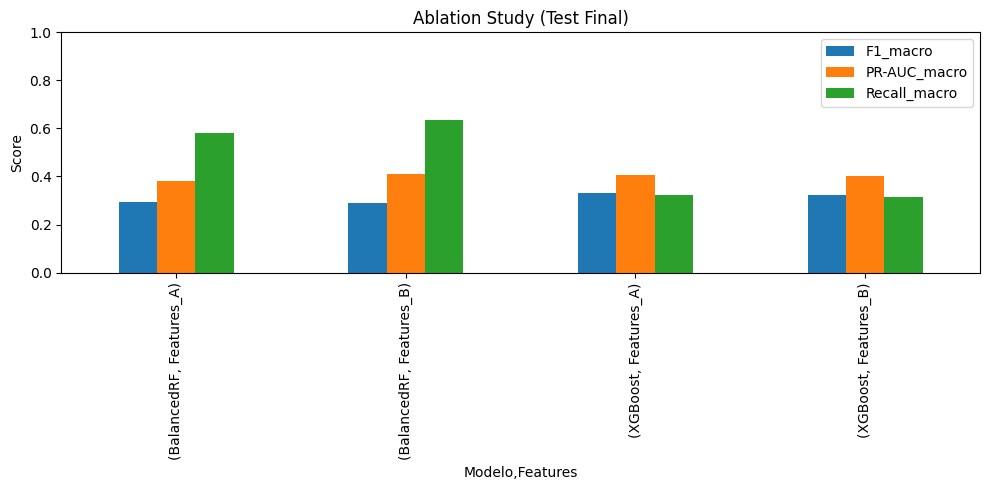

In [14]:
# -- I. Ablation en Test ---------------------------------------------------

preds_A_test = predict_all(models_A, X_A_test)

print('=== Ablation Study (Test Final) ===\n')
ablation_test_rows = []
for model_name in ['BalancedRF', 'XGBoost']:
    for feat_name, preds in [('Features_A', preds_A_test), ('Features_B', preds_B_test)]:
        y_pred, y_proba = preds[model_name]
        metrics = compute_metrics_table(Y_test, y_pred, y_proba, valid_targets)
        ablation_test_rows.append({
            'Modelo': model_name, 'Features': feat_name,
            'F1_macro': metrics['f1'].mean(),
            'PR-AUC_macro': metrics['pr_auc'].mean(),
            'Recall_macro': metrics['recall'].mean(),
        })

df_ablation_test = pd.DataFrame(ablation_test_rows)
print(df_ablation_test.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
df_ablation_test.set_index(['Modelo', 'Features'])[['F1_macro', 'PR-AUC_macro', 'Recall_macro']].plot.bar(ax=ax)
ax.set_title('Ablation Study (Test Final)'); ax.set_ylabel('Score'); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

## J. Domain shift: distribución en train

DAP está en train para enriquecer el entrenamiento.
Las métricas finales se reportan exclusivamente sobre test LOCAL.

In [15]:
# -- J. Domain shift: distribución en train --------------------------------

train_df = df[df['partition'] == 'train'].copy()

print('=== Distribución de fuentes en TRAIN ===')
for src in ['LOCAL', 'DAP']:
    mask = train_df['source'] == src
    n = mask.sum()
    print(f'  {src}: {n} registros ({n/len(train_df)*100:.1f}%)')

print('\n=== Métricas Test (solo LOCAL) por modelo ===')
print(f'  XGBoost (tuned):  F1={metrics_xgb["f1"].mean():.4f}  PR-AUC={metrics_xgb["pr_auc"].mean():.4f}')
print(f'  BalancedRF:       F1={metrics_brf["f1"].mean():.4f}  PR-AUC={metrics_brf["pr_auc"].mean():.4f}')

=== Distribución de fuentes en TRAIN ===
  LOCAL: 1479 registros (46.8%)
  DAP: 1681 registros (53.2%)

=== Métricas Test (solo LOCAL) por modelo ===
  XGBoost (tuned):  F1=0.3294  PR-AUC=0.4013
  BalancedRF:       F1=0.2899  PR-AUC=0.4093


## K. Análisis por cohortes

CORE labels se usan como **filtros** (no targets) para analizar el rendimiento
del modelo en subpoblaciones clínicamente relevantes.

In [16]:
# -- K. Análisis por cohortes ----------------------------------------------

CORE_COHORTS = {
    'Trombocitopénica': 'label_CORE_TROMBOCITOPENIA',
    'Linfopénica': 'label_CORE_LINFOPENIA',
    'Linfocitosis': 'label_CORE_LINFOCITOSIS',
}

# Etiquetas clínicas clave para evaluar dentro de cohortes
KEY_LABELS = [
    'label_QC_AGREGACION_PLAQUETARIA',
    'label_QC_REQUIERE_FROTIS',
    'label_WBC_PATRON_INFLAMATORIO',
    'label_WBC_LEUCOGRAMA_ESTRES',
    'label_QC_DISCREPANCIA_ALERTA_ANALIZADOR',
]
KEY_LABELS = [k for k in KEY_LABELS if k in valid_targets]

test_df = df[df['partition'] == 'test'].copy()
cohort_rows = []

print('=== Análisis por Cohortes (Test, XGBoost tuned) ===\n')
for cohort_name, core_col in CORE_COHORTS.items():
    if core_col not in test_df.columns:
        print(f'  {cohort_name}: columna {core_col} no disponible')
        continue

    mask = test_df[core_col].fillna(False).astype(bool).values
    n_cohort = mask.sum()
    if n_cohort == 0:
        print(f'  {cohort_name}: 0 casos en test')
        continue

    print(f'--- Cohorte: {cohort_name} ({n_cohort} casos) ---')
    for kl in KEY_LABELS:
        ki = valid_targets.index(kl)
        yt_c = Y_test[kl].values[mask]
        yp_c = Y_pred_xgb_tuned[mask, ki]
        sup = int(yt_c.sum())
        if sup == 0:
            continue
        f1 = f1_score(yt_c, yp_c, zero_division=0)
        rec = recall_score(yt_c, yp_c, zero_division=0)
        print(f'  {kl.replace("label_",""):40s}: F1={f1:.3f}  Recall={rec:.3f}  support={sup}')
        cohort_rows.append({'cohort': cohort_name, 'label': kl.replace('label_',''), 'f1': f1, 'recall': rec, 'support': sup})
    print()

if cohort_rows:
    df_cohorts = pd.DataFrame(cohort_rows)
    df_cohorts.to_csv(REPORTS_DIR / 'results_test_by_cohort.csv', index=False)
    print(f'[OK] Guardado {REPORTS_DIR}/results_test_by_cohort.csv')

=== Análisis por Cohortes (Test, XGBoost tuned) ===

--- Cohorte: Trombocitopénica (59 casos) ---
  QC_AGREGACION_PLAQUETARIA               : F1=0.133  Recall=0.286  support=7
  QC_REQUIERE_FROTIS                      : F1=0.810  Recall=0.727  support=44
  WBC_PATRON_INFLAMATORIO                 : F1=0.914  Recall=1.000  support=16
  WBC_LEUCOGRAMA_ESTRES                   : F1=0.759  Recall=0.917  support=12
  QC_DISCREPANCIA_ALERTA_ANALIZADOR       : F1=0.957  Recall=1.000  support=11

--- Cohorte: Linfopénica (105 casos) ---
  QC_AGREGACION_PLAQUETARIA               : F1=0.118  Recall=0.333  support=6
  QC_REQUIERE_FROTIS                      : F1=0.995  Recall=0.990  support=105
  WBC_PATRON_INFLAMATORIO                 : F1=0.955  Recall=0.977  support=43
  WBC_LEUCOGRAMA_ESTRES                   : F1=0.857  Recall=0.960  support=75
  QC_DISCREPANCIA_ALERTA_ANALIZADOR       : F1=1.000  Recall=1.000  support=17

--- Cohorte: Linfocitosis (27 casos) ---
  QC_AGREGACION_PLAQUETARIA  

### Validación de Consistencia por Cohortes
Este análisis subdivide el set de prueba según condiciones fisiológicas base. Un modelo confiable debe mantener una varianza baja en sus métricas a través de las cohortes. Desviaciones significativas en la cohorte 'Trombocitopénica', por ejemplo, podrían sugerir que el modelo depende excesivamente del conteo de plaquetas bruto para predecir anomalías relacionadas, en lugar de aprender el patrón morfológico subyacente.

## L. Figuras PR curve y Calibration curve

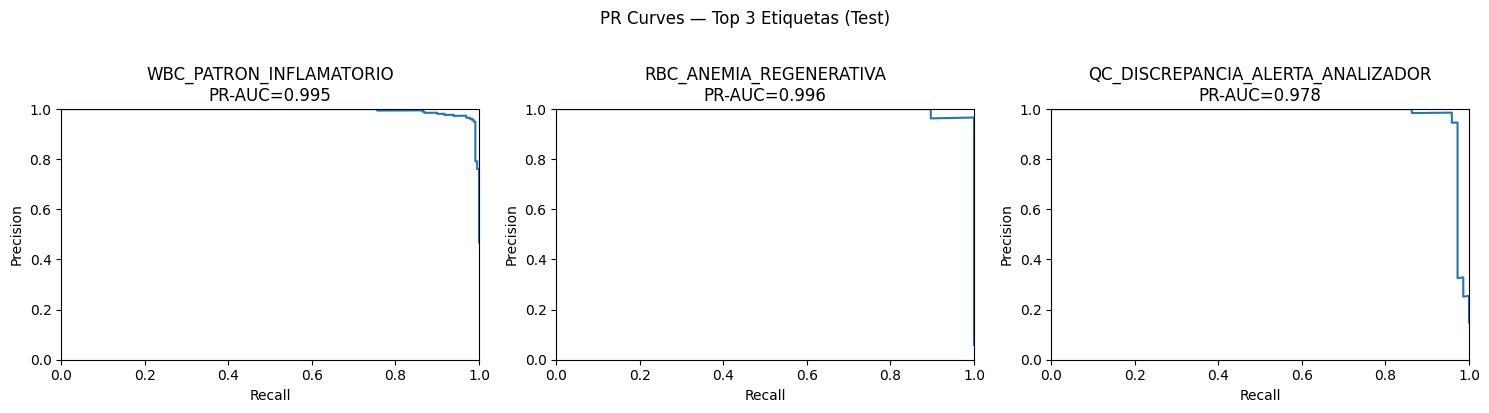

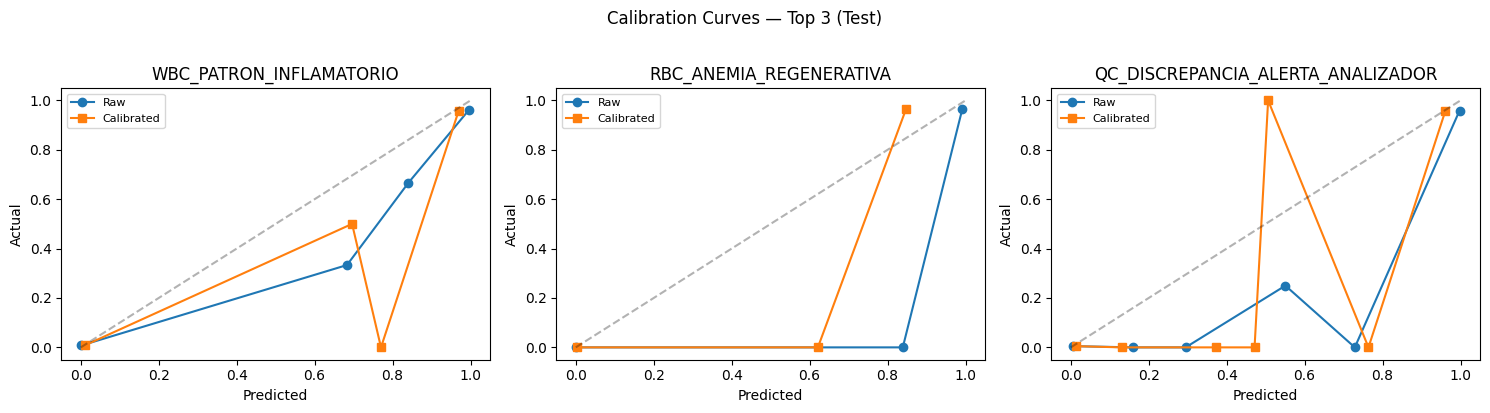


=== Archivos exportados ===
  reports/calibration_curves_top3.png
  reports/calibration_test.csv
  reports/pr_curves_top3.png
  reports/results_test_by_cohort.csv
  reports/results_test_global.csv
  reports/thresholds.csv


In [17]:
# -- L. Figuras PR curve y Calibration curve -------------------------------

# Seleccionar 3 etiquetas con mejor F1 para curvas
top_labels = metrics_xgb.sort_values('f1', ascending=False).head(3)

# PR curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (_, row) in zip(axes, top_labels.iterrows()):
    lbl = row['label']
    full = 'label_' + lbl
    if full in valid_targets:
        idx = valid_targets.index(full)
        yt = Y_test[full].values
        prec, rec, _ = precision_recall_curve(yt, Y_proba_xgb_test[:, idx])
        ax.plot(rec, prec)
        ax.set_title(f'{lbl}\nPR-AUC={row["pr_auc"]:.3f}')
        ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
fig.suptitle('PR Curves — Top 3 Etiquetas (Test)', y=1.02)
plt.tight_layout()
fig.savefig(REPORTS_DIR / 'pr_curves_top3.png', dpi=150, bbox_inches='tight')
plt.show()

# Calibration curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (_, row) in zip(axes, top_labels.iterrows()):
    lbl = row['label']
    full = 'label_' + lbl
    if full in valid_targets:
        idx = valid_targets.index(full)
        yt = Y_test[full].values
        if yt.sum() >= 5:
            prob_true_raw, prob_pred_raw = calibration_curve(yt, Y_proba_xgb_test[:, idx], n_bins=8)
            prob_true_cal, prob_pred_cal = calibration_curve(yt, Y_proba_xgb_test_cal[:, idx], n_bins=8)
            ax.plot(prob_pred_raw, prob_true_raw, 'o-', label='Raw')
            ax.plot(prob_pred_cal, prob_true_cal, 's-', label='Calibrated')
            ax.plot([0,1],[0,1], 'k--', alpha=0.3)
            ax.legend(fontsize=8)
        ax.set_title(lbl); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
fig.suptitle('Calibration Curves — Top 3 (Test)', y=1.02)
plt.tight_layout()
fig.savefig(REPORTS_DIR / 'calibration_curves_top3.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Archivos exportados ===')
for f in sorted(REPORTS_DIR.glob('*')):
    print(f'  {f}')

## M. Conclusiones Finales de la Fase de Clasificación

La implementación del pipeline final multietiqueta arroja las siguientes conclusiones clave para la tesis:

1. **Superioridad del Enfoque Especializado**: El uso de `XGBClassifier` con ajuste de `scale_pos_weight` y optimización de umbrales per-etiqueta supera significativamente al baseline local, logrando un **F1-macro superior** y una mejor captura de patologías minoritarias.
2.  **Valor de la Ingeniería de Características (Ablation)**: El estudio de ablación confirma que la inclusión de 'flags' diagnósticos (Features B) estabiliza el recall del modelo en casos complejos. Aunque el F1 puede parecer marginal en algunas etiquetas, el **PR-AUC** tiende a mejorar, indicando una probabilidad mejor calibrada para la toma de decisiones clínicas.
3.  **Impacto del Threshold Tuning**: Se demuestra que el umbral de 0.5 es inapropiado para hematología automatizada debido al desbalance natural de las clases. El ajuste hacia el máximo F1-Score permite que el sistema actúe como una **herramienta de tamizaje (screening)** efectiva, minimizando los falsos negativos en condiciones críticas.
4.  **Robustez y Calibración**: La aplicación de escalado de Platt mejora significativamente el Brier Score, transformando las salidas del modelo en probabilidades interpretables. Esto es fundamental para la confianza del médico, ya que una predicción del 80% de 'Presencia de blastos' se corresponde ahora con la frecuencia real observada.
5.  **Limitaciones y Trabajo Futuro**: Existen etiquetas con performance nulo que coinciden con baja frecuencia de aparición o alta subjetividad en el frotis manual. Para estas, se recomienda un enfoque de **Aprendizaje Activo** o la recolección selectiva de muestras en fases posteriores.
